### **UTILIZATION OF CNN2D ON MNIST DATASET**

In [16]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# tensorflow and scikit learn imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [17]:
# loading the dataset

train_path = pd.read_csv("dataset/mnist_train.csv")
test_path = pd.read_csv("dataset/mnist_test.csv")

print("Dataset Loaded Successfully!")

# showing the shapes if each csv and showing the first 5 records
print(f"Train Shape: {train_path.shape}")
print(f"Test Shape: {test_path.shape}")
print(f"First 5 records of the train dataset: \n {train_path.head()}")

# showing the columns for both train and test csvs
print(f"Train CSV Columns: {train_path.columns.tolist()}")
print(f"Test CSV Columns: {test_path.columns.tolist()}")

Dataset Loaded Successfully!
Train Shape: (60000, 785)
Test Shape: (10000, 785)
First 5 records of the train dataset: 
    label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
Train CSV Columns: ['label', '1x1', '1x

In [18]:
# preprocessing train set

X = train_path.iloc[:, 1:].values / 255.0
y = train_path.iloc[:, 0].values

X = X.reshape(-1, 28, 28, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

y_train = to_categorical(y_train, 10)
y_val   = to_categorical(y_val, 10)

print(f"Original X shape: {X.shape}")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")


# preprocessing test set - dropping the label column

X_test = test_path.iloc[:, 1:].values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
print(f"X_test: {X_test.shape}")

Original X shape: (60000, 28, 28, 1)
X_train: (54000, 28, 28, 1)
X_val: (6000, 28, 28, 1)
X_test: (10000, 28, 28, 1)


In [19]:
from tensorflow.keras.callbacks import EarlyStopping

# building the model

def build_cnn2d_model():
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128,activation='relu'),
        Dropout(0.5),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_cnn2d_model()
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

c:\PROGRAMMING\data-mining\sir-cy\datamining\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# === NO AUGMENTATION MODEL ===

print("Training started for MODEL with NO AUGMENTATION!")
no_aug_model = build_cnn2d_model()
no_aug_history = no_aug_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

# === AUGMENTATION MODEL ===

print("Training started for MODEL with AUGMENTATION!")
datagen = ImageDataGenerator(rotation_range=10,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             zoom_range=0.1)
datagen.fit(X_train)

augmented_model = build_cnn2d_model()
augmented_history = augmented_model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Training started for MODEL with NO AUGMENTATION!
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8988 - loss: 0.3276 - val_accuracy: 0.9760 - val_loss: 0.0803
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9705 - loss: 0.1001 - val_accuracy: 0.9810 - val_loss: 0.0632
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9775 - loss: 0.0745 - val_accuracy: 0.9858 - val_loss: 0.0559
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9818 - loss: 0.0605 - val_accuracy: 0.9850 - val_loss: 0.0505
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9847 - loss: 0.0502 - val_accuracy: 0.9855 - val_loss: 0.0527
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9861 - loss: 0.0450 - val_accuracy: 0.9880 - val_loss: 0.0410
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9884 - loss: 0.0403 - val_accuracy: 0.9872 - val_loss: 0.0511
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1

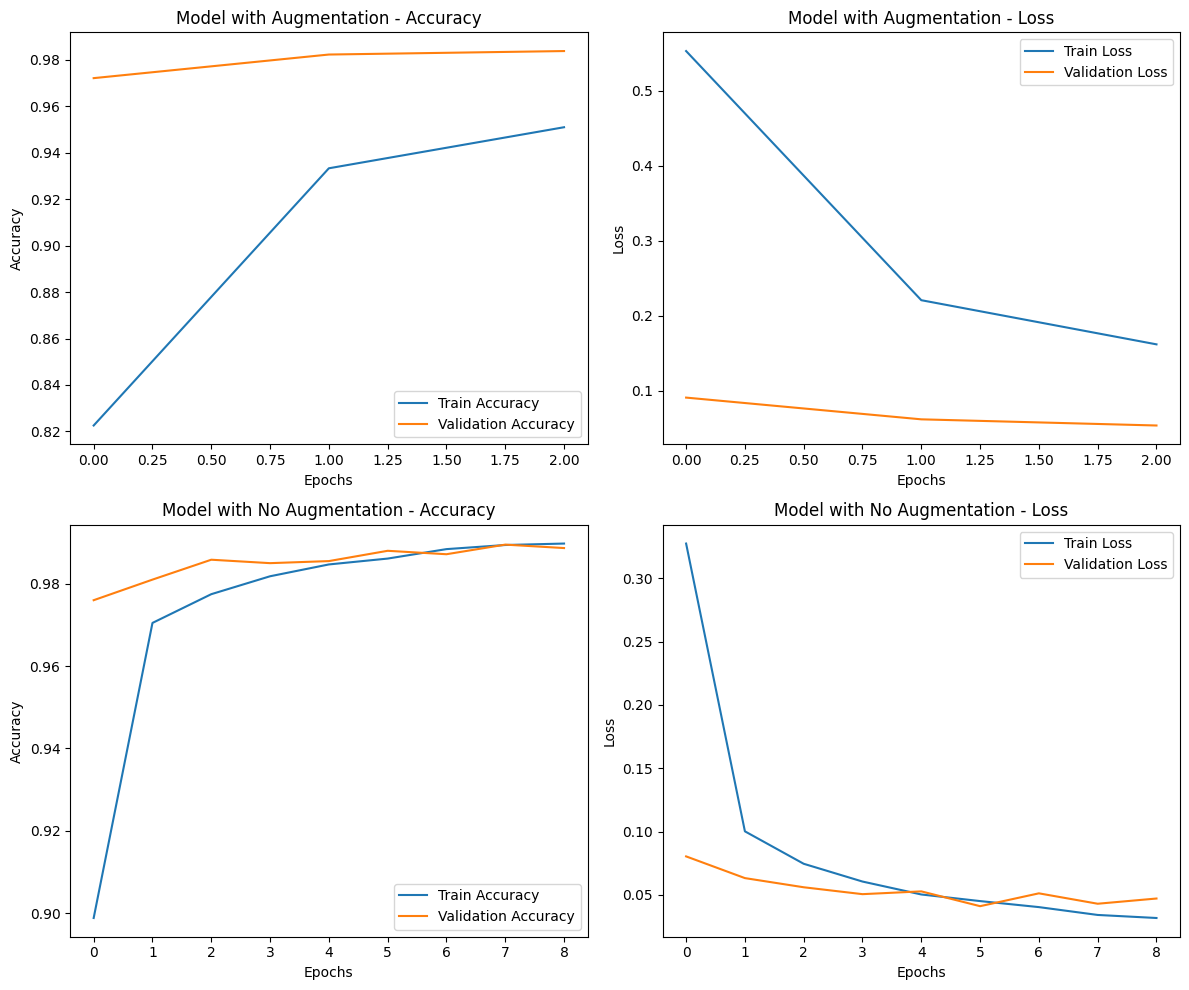

In [21]:
# plot results

plt.figure(figsize=(12,10)) # plot size

# subplot for augmented accuracy and val_acc
plt.subplot(2,2,1)
plt.plot(augmented_history.history['accuracy'], label='Train Accuracy')
plt.plot(augmented_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with Augmentation - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# subplot for augmented loss and val_loss
plt.subplot(2,2,2)
plt.plot(augmented_history.history['loss'], label='Train Loss')
plt.plot(augmented_history.history['val_loss'], label='Validation Loss')
plt.title('Model with Augmentation - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# subplot for non-augmented accuracy and val_acc
plt.subplot(2,2,3)
plt.plot(no_aug_history.history['accuracy'], label='Train Accuracy')
plt.plot(no_aug_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model with No Augmentation - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# subplot for nonaugmented loss and val_loss
plt.subplot(2,2,4)
plt.plot(no_aug_history.history['loss'], label='Train Loss')
plt.plot(no_aug_history.history['val_loss'], label='Validation Loss')
plt.title('Model with No Augmentation - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# test prediction using cnn 2d model

preds = augmented_model.predict(X_test)
y_pred = np.argmax(preds, axis=1)

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(X_test)+1),
    "Label": y_pred
})

submission.to_csv("cnn2d_submission.csv", index=False)
print(submission.head())